In [ ]:
!pip install -U diffusers transformers accelerate -q

In [1]:
import torch, gc, requests
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionXLPipeline

print(f"GPU: {torch.cuda.get_device_name(0)}")

pipe = StableDiffusionXLPipeline.from_pretrained(
    "playgroundai/playground-v2.5-1024px-aesthetic",
    torch_dtype=torch.float16,
    use_safetensors=True,
)
pipe = pipe.to("cuda")

print("✅ الموديل جاهز")

GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

✅ الموديل جاهز


In [2]:
def brief_to_image_prompt(b):
    return f"{b['logo_direction']}, professional corporate branding, flat vector design, Adobe Illustrator style, geometric, minimalist icon, clean background, no text, no cartoon, no mascot"

briefs = requests.get("https://raw.githubusercontent.com/maram-elaian/brandora/main/data/test_briefs.json").json()[:5]

generated_files = []
for brief in briefs:
    print(f"⏳ {brief['id']}...")
    image = pipe(
        brief_to_image_prompt(brief),
        num_inference_steps=25,
        guidance_scale=3.0,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

    filename = f"Playground_v2_{brief['id']}.png"
    image.save(filename)
    generated_files.append(filename)
    print(f"✅ {brief['id']}")

    del image
    gc.collect()
    torch.cuda.empty_cache()

print("✅ خلصت")

⏳ BR001...


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


✅ BR001
⏳ BR002...


  0%|          | 0/25 [00:00<?, ?it/s]

...

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


✅ BR004
⏳ BR005...


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


✅ BR005
✅ خلصت


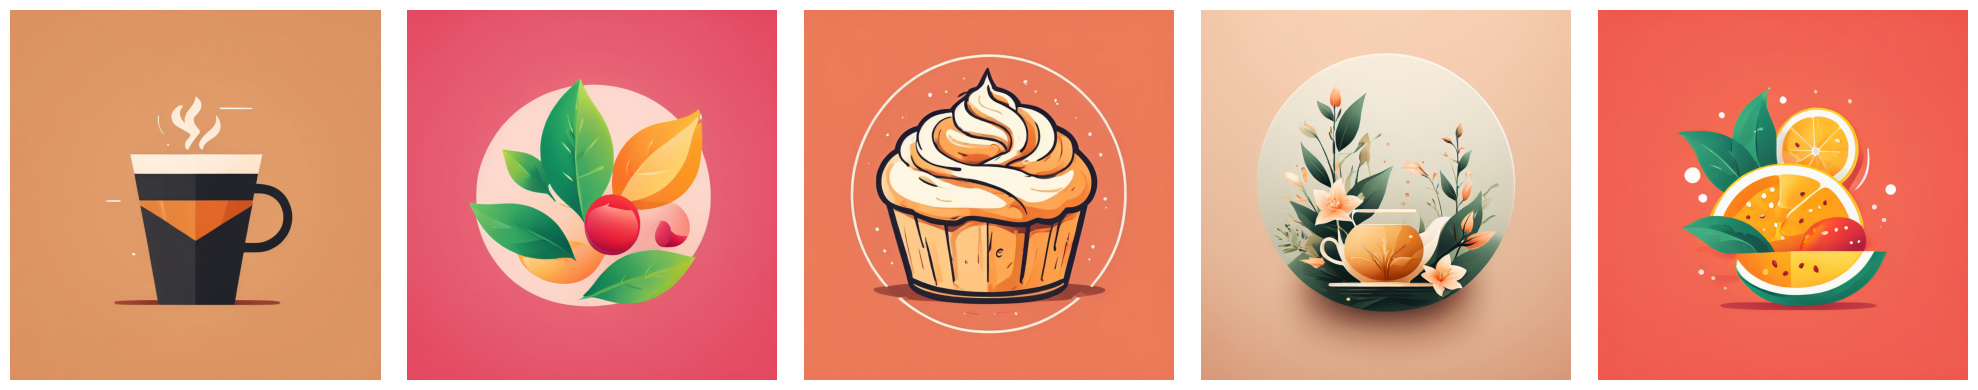

In [3]:
fig, axes = plt.subplots(1, len(generated_files), figsize=(20, 4))
for ax, f in zip(axes, generated_files):
    ax.imshow(Image.open(f))
    ax.axis('off')
plt.tight_layout()
plt.show()